# MP2RAGE: one inversion, two trains, and a label that has to be right

One inversion, **two** GRE trains at different inversion times and different flip angles, then
recovery. The same lines are acquired at both TIs, so a shot produces two images of the same
k-space at two points on the recovery curve — and the ratio of those two images cancels the
receive field, which is the entire reason the sequence exists.

```text
UNI = Re(S₁ · conj(S₂)) / (|S₁|² + |S₂|²)
```

Everything the timing needs was established in
[`../mprage_2d/01_build.ipynb`](../mprage_2d/01_build.ipynb): TI runs from
`IRPrep.time_to_center()` to `GRE2D.time_to_center_line(...)`, and both ends are module methods
because a tree of events cannot know either. **This notebook is written to be read on its own**
— it does not import or subclass `MPRAGE2D`, because a tutorial that only makes sense after
another one is a worse tutorial than thirty duplicated lines.

What is genuinely new here is the **`SET` label**, and a trap in it that produces a legal `.seq`
file containing half the data in the wrong contrast.

**Output:** one `.seq` file in `seq/` and the nominal k-space beside it.

## 0. The scanner, and the protocol

`ti_s` and `flip_deg` are **pairs** rather than two arguments each, because neither is meaningful
alone and a pair cannot be half-supplied.

**The two TIs bracket the tissues of interest.** The first is short enough that white matter is
still inverted and the second long enough that it has recovered, so the two images differ in
sign as well as in magnitude — which is what makes `Re(S₁ conj(S₂))` carry T1 information rather
than just a ratio of magnitudes.

**The flip angles are low and the second is higher than the first.** The first train has the
whole inverted magnetisation to spend and must not spend much of it, because the second train
has to run on what is left; by the second the magnetisation is already reduced, so a slightly
larger angle buys signal without costing the first contrast anything.

`INVERSION_PULSE = 'block'` for the reason
[`../mprage_2d/02`](../mprage_2d/02_simulate_and_reconstruct.ipynb) measures: the simulator this
example is checked against applies a pulse as an instantaneous rotation by its integrated flip
angle, which is 289° for the adiabatic default and does not invert.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (220.0, 220.0)
MATRIX = (128, 128)
THICKNESS_MM = 5.0
BANDWIDTH_HZ_PX = 400.0
SPOIL_CYCLES = 4.0

TI_S = (0.70, 2.20)          # increasing, and far enough apart for the first train to finish
FLIP_DEG = (4.0, 5.0)
SHOT_INTERVAL_S = 4.0
TURBO = 32
DUMMY_SHOTS = 5              # whole shots; ../mprage_2d/02 measures why five

INVERSION_PULSE = 'block'
INVERSION_DURATION_S = 1e-3
INVERSION_SPOIL_CYCLES = 8.0

NX, NY = MATRIX
CENTER_LINE = NY // 2
N_SHOTS = NY // TURBO

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)

grad_raster = sc.Raster(opts.grad_raster_time)
block_raster = sc.Raster(opts.block_duration_raster)

print(f'{NX} x {NY} over {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'{N_SHOTS} shots of {TURBO} lines at TI = '
      f'{TI_S[0] * 1e3:.0f} and {TI_S[1] * 1e3:.0f} ms, flips {FLIP_DEG[0]:.0f} and '
      f'{FLIP_DEG[1]:.0f} deg')
print(f'{N_SHOTS * SHOT_INTERVAL_S:.0f} s of acquisition, twice the data of one MPRAGE '
      f'of the same matrix')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128 over 220 x 220 mm, 5 mm slice
4 shots of 32 lines at TI = 700 and 2200 ms, flips 4 and 5 deg
16 s of acquisition, twice the data of one MPRAGE of the same matrix


---
# 1. One inversion, two trains

`GRE2D` is reused per *train*, and there are two of them because the flip angles differ. Both are
cheap: the waveforms are designed once each, and a shot is two calls.

In [2]:
inv = sc.modules.IRPrep(
    opts=opts, thickness_mm=None,
    pulse=INVERSION_PULSE, duration_s=INVERSION_DURATION_S,
    spoil_cycles_per_voxel=INVERSION_SPOIL_CYCLES, spoil_voxel_mm=THICKNESS_MM,
)
gre = tuple(
    sc.modules.GRE2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     flip_deg=flip, bandwidth_hz_px=BANDWIDTH_HZ_PX,
                     spoil_cycles_per_voxel=SPOIL_CYCLES)
    for flip in FLIP_DEG
)

prep_s = inv().duration
train_s = TURBO * gre[0].tr.tr_s

print(f'inversion block  {prep_s * 1e3:8.3f} ms   centre at '
      f'{inv.time_to_center() * 1e3:.3f} ms')
print(f'train TR         {gre[0].tr.tr_s * 1e3:8.3f} ms   TE {gre[0].tr.te_s * 1e3:.3f} ms')
print(f'one train        {train_s * 1e3:8.3f} ms   ({TURBO} lines)')
print()
print(f'TI separation    {(TI_S[1] - TI_S[0]) * 1e3:8.3f} ms   '
      f'and the first train needs {train_s * 1e3:.3f} ms of it')
assert TI_S[1] > TI_S[0], 'ti_s must be increasing'

inversion block     2.340 ms   centre at 0.600 ms
train TR            7.890 ms   TE 3.368 ms
one train         252.480 ms   (32 lines)

TI separation    1500.000 ms   and the first train needs 252.480 ms of it


### Where the two trains go

Each train is placed by the same three terms as a single-TI MPRAGE, once per TI:

```python
t_train[i] = inv.time_to_center() + ti_s[i] - gre[i].time_to_center_line(lines=segment)
```

The two trains use the **same** `segment`, so the two images are of the same k-space and the
ratio below is defined pixel by pixel. Their `time_to_center_line` is the same number here only
because both trains share a TR; nothing assumes it, and the arithmetic is per train.

In [3]:
def train_offsets_s(segment):
    """Seconds from the start of a shot to the start of each train."""
    return tuple(
        float(grad_raster.ceil(
            inv.time_to_center() + ti - module.time_to_center_line(lines=segment)))
        for ti, module in zip(TI_S, gre)
    )


segment = tuple(sorted(range(CENTER_LINE - TURBO // 2, CENTER_LINE + TURBO // 2),
                       key=lambda line: (abs(line - CENTER_LINE), line)))
first, second = train_offsets_s(segment)

print(f'train 1 starts   {first * 1e3:9.3f} ms into the shot, ends '
      f'{(first + train_s) * 1e3:9.3f} ms')
print(f'train 2 starts   {second * 1e3:9.3f} ms into the shot, ends '
      f'{(second + train_s) * 1e3:9.3f} ms')
print(f'gap between them {(second - first - train_s) * 1e3:9.3f} ms')

train 1 starts     695.640 ms into the shot, ends   948.120 ms
train 2 starts    2195.640 ms into the shot, ends  2448.120 ms
gap between them  1247.520 ms


### The floor, and it is a different one from MPRAGE's

MPRAGE's minimum TI keeps the train clear of the inversion block. MP2RAGE inherits that for the
**first** TI and adds a second: `ti_s[1] - ti_s[0]` has to exceed the first train's duration, or
the two trains overlap. `LogicBlock` permits overlap silently, so what comes out of too small a
separation is two trains summed on every axis rather than an error.

In [4]:
def min_ti_s(segment):
    """The floor on the first TI: the prep tail plus where k = 0 sits in the train."""
    return prep_s - inv.time_to_center() + gre[0].time_to_center_line(lines=segment)


def min_ti_separation_s(segment):
    """The floor on ti_s[1] - ti_s[0]: the first train has to finish before the second starts."""
    offsets = train_offsets_s(segment)
    return (TI_S[1] - TI_S[0]) - (offsets[1] - offsets[0] - train_s)


print(f'min TI[0]            {min_ti_s(segment) * 1e3:9.3f} ms   (asked '
      f'{TI_S[0] * 1e3:.3f} ms)')
print(f'min TI separation    {min_ti_separation_s(segment) * 1e3:9.3f} ms   (asked '
      f'{(TI_S[1] - TI_S[0]) * 1e3:.3f} ms)')
assert TI_S[0] >= min_ti_s(segment)
assert TI_S[1] - TI_S[0] >= min_ti_separation_s(segment)

min TI[0]                6.708 ms   (asked 700.000 ms)
min TI separation      252.480 ms   (asked 1500.000 ms)


---
# 2. The `SET` label, and the trap in it

The two trains are distinguished by a label the reconstruction reads to separate the TIs.
Without it the two contrasts arrive interleaved with nothing but acquisition order to tell them
apart — and segmentation has already made acquisition order untrustworthy, which is the same
argument that made `LIN` load-bearing.

**Emit `SET=0` before *every* first train, not once at the start of the sequence.** Pulseq labels
are **stateful**: `type='SET'` writes a value that persists until something changes it. Set `0`
once at the very beginning and `1` before each second train, and shot 2's *first* train inherits
`SET=1` from shot 1's second train. Every shot after the first is then mislabelled, half the data
lands in the wrong contrast, and the `.seq` file is perfectly legal.

One label per train, unconditionally. It costs one event and removes the failure.

`SET` rather than `ECO` because these are two readouts after **separate excitations**, not two
echoes of one, so `ECO` would misdescribe them in the file. If a downstream ISMRMRD pipeline
expects differing TI in the `contrast` counter then `ECO` is the pragmatic swap — the requirement
is only that the label the sequence writes and the label the reconstruction reads are the same
one, so whichever is chosen belongs in the `.seq` definitions too.

In [5]:
def shot(segment, t_shot=0.0, *, acquire=True, offsets=None):
    """
    One shot: inversion, train at TI[0], train at TI[1].  The recovery is the gap after it.

    `offsets` is passed in by the loop so that **every shot inherits the geometry of the one
    carrying k = 0** -- only that shot's TI is physically meaningful, and the rest exist to put
    each line at the same point of its own train.
    """
    offsets = train_offsets_s(segment) if offsets is None else offsets
    out = sc.LogicBlock('shot')
    if acquire:
        out.add(t_shot, pp.make_label(type='SET', label='TRID', value=1))
    out.add(t_shot, inv())
    for index, offset in enumerate(offsets):
        if acquire:
            # Unconditionally, both of them, every shot.  This is the whole fix.
            out.add(t_shot + offset, pp.make_label(type='SET', label='SET', value=index))
        out.add(t_shot + offset, train(segment, index, acquire=acquire))
    return out


def train(segment, index, *, acquire=True):
    """Train `index`.  `dummies=0`: the steady state here is shot-to-shot, as in MPRAGE."""
    module = gre[index]
    if acquire:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', sc.SeqCraftWarning)
            return module(lines=segment, dummies=0)
    out = sc.LogicBlock('GRE2D')
    for n, line in enumerate(segment):
        out.add(n * module.tr.tr_s,
                module.tr(line=line, phase_deg=module.phase_deg(n), acquire=False))
    return out


one = shot(segment)
print('\n'.join(one.describe().splitlines()[:8]))
print('    ...')

shot  2448.12 ms
  +0.0 us  labelset
  +0.0 us  IRPrep  2.34 ms
    +0.0 us  rf
    +1130.0 us  spoiler  1.21 ms
      +0.0 us  trap z
  +695640.0 us  labelset
  +695640.0 us  GRE2D  252.48 ms
    ...


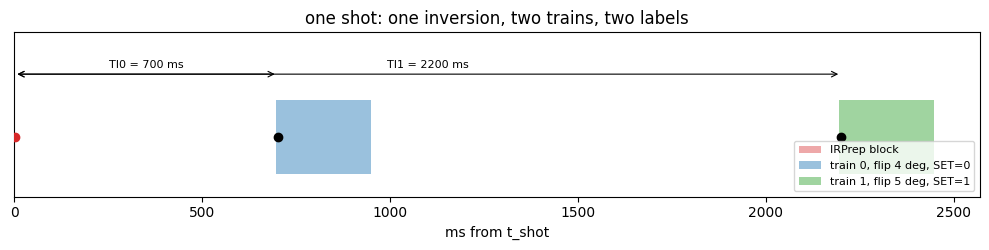

In [6]:
fig, ax = plt.subplots(figsize=(10, 2.6))
offsets = train_offsets_s(segment)
ax.barh(0, prep_s * 1e3, left=0, height=0.5, color='C3', alpha=0.4, label='IRPrep block')
for index, (offset, colour) in enumerate(zip(offsets, ('C0', 'C2'))):
    ax.barh(0, train_s * 1e3, left=offset * 1e3, height=0.5, color=colour, alpha=0.45,
            label=f'train {index}, flip {FLIP_DEG[index]:.0f} deg, SET={index}')
    t_k0 = (offset + gre[index].time_to_center_line(lines=segment)) * 1e3
    ax.plot([t_k0], [0], 'ko', ms=6, zorder=5)
    ax.annotate('', xy=(t_k0, 0.42), xytext=(inv.time_to_center() * 1e3, 0.42),
                arrowprops={'arrowstyle': '<->', 'color': 'k', 'lw': 0.8})
    ax.text(0.5 * (inv.time_to_center() * 1e3 + t_k0), 0.46,
            f'TI{index} = {TI_S[index] * 1e3:.0f} ms', ha='center', fontsize=8)
ax.plot([inv.time_to_center() * 1e3], [0], 'o', color='C3', ms=6, zorder=5)
ax.set(xlabel='ms from t_shot', yticks=[], ylim=(-0.4, 0.7),
       title='one shot: one inversion, two trains, two labels')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()

### Both TIs land where they were asked to

In [7]:
k = sc.kspace(one, opts)
acquired = list(segment) * 2                       # both trains, same lines, in order
t_adc = k['t_adc'].reshape(len(acquired), NX)

for index in range(2):
    row = index * len(segment) + segment.index(CENTER_LINE)
    measured = float(t_adc[row, NX // 2]) - inv.time_to_center()
    assert abs(measured - TI_S[index]) < 1e-5, f'TI{index} is {measured * 1e3:.3f} ms'
    print(f'TI{index} measured {measured * 1e3:9.4f} ms   (asked {TI_S[index] * 1e3:.4f} ms)')

TI0 measured  700.0077 ms   (asked 700.0000 ms)
TI1 measured 2200.0077 ms   (asked 2200.0000 ms)


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 256 blocks over the vector-norm limit (legal on real amplifiers): shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 698.790 ms), shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 698.790 ms), shot.GRE2D.GRE2DTR.PhaseEncode, shot.GRE2D.GRE2DTR.spoiler (grad 141% at 701.890 ms), shot.GRE2D.GRE2DTR.PhaseEncode, shot.GRE2D.GRE2DTR.spoiler (slew 139% at 701.890 ms), shot.GRE2D.GRE2DTR.CartesianLine, shot.GRE2D.GRE2DTR.Excitation, shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 706.680 ms) (+251 more sites)
  seq = compile_sequence(tree, opts)


---
# 3. The scan, and four checks on the label

Segmentation is the same as MPRAGE's: interleave the lines into shots so every shot spans
k-space, and order centrically within each shot.

In [8]:
def segments_of(lines, turbo):
    """Interleave `lines` into shots of `turbo`, centric within each shot."""
    n_shots = len(lines) // turbo
    return tuple(
        tuple(sorted(lines[shot::n_shots], key=lambda line: (abs(line - CENTER_LINE), line)))
        for shot in range(n_shots)
    )


def scan(segments, *, dummy_shots=DUMMY_SHOTS):
    """One shot per segment, after `dummy_shots` unacquired ones."""
    interval = float(block_raster.ceil(SHOT_INTERVAL_S))
    reference = next(s for s in segments if CENTER_LINE in s)
    offsets = train_offsets_s(reference)
    out = sc.LogicBlock('scan')
    for index in range(-dummy_shots, len(segments)):
        out.add((index + dummy_shots) * interval,
                shot(segments[max(index, 0)], acquire=index >= 0, offsets=offsets))
    return out


segments = segments_of(tuple(range(NY)), TURBO)
raw = scan(segments)
raw_seq = sc.compile(raw, opts, name='mp2rage_2d')

labels = raw_seq.evaluate_labels(evolution='adc')
lin = np.asarray(labels['LIN']).astype(int)
sets = np.asarray(labels['SET']).astype(int)

print(f'{len(raw_seq.block_events)} pulseq blocks, {raw_seq.duration()[0]:.2f} s, '
      f'{len(lin)} readouts')

2348 pulseq blocks, 34.45 s, 256 readouts


C:\Users\bughh\AppData\Local\Temp\ipykernel_30768\310251371.py:24: SeqCraftWarning: 2304 blocks over the vector-norm limit (legal on real amplifiers): scan.shot.GRE2D.GRE2DTR.CartesianLine, scan.shot.GRE2D.GRE2DTR.Excitation, scan.shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 698.790 ms), scan.shot.GRE2D.GRE2DTR.CartesianLine, scan.shot.GRE2D.GRE2DTR.Excitation, scan.shot.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 698.790 ms), scan.shot.GRE2D.GRE2DTR.PhaseEncode, scan.shot.GRE2D.GRE2DTR.spoiler (grad 141% at 701.890 ms), scan.shot.GRE2D.GRE2DTR.PhaseEncode, scan.shot.GRE2D.GRE2DTR.spoiler (slew 139% at 701.890 ms), scan.shot.GRE2D.GRE2DTR.CartesianLine, scan.shot.GRE2D.GRE2DTR.Excitation, scan.shot.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 706.680 ms) (+2299 more sites)
  raw_seq = sc.compile(raw, opts, name='mp2rage_2d')


In [9]:
# 1. SET partitions the readouts into two equal halves.  With more than one shot: a single-shot
#    test passes with the stateful-label bug present, which is what makes it worth stating.
assert len(segments) > 1, 'this check is vacuous with one shot'
assert sorted(np.bincount(sets).tolist()) == [NY, NY], np.bincount(sets)

# 2. For **every** shot, the readouts of its first train carry SET=0 -- not just the first shot's.
per_shot = sets.reshape(len(segments), 2, TURBO)
assert (per_shot[:, 0, :] == 0).all(), 'a later shot inherited SET=1 from the shot before it'
assert (per_shot[:, 1, :] == 1).all()

# 3. Both trains acquire the same lines, in the same order.
per_shot_lin = lin.reshape(len(segments), 2, TURBO)
assert (per_shot_lin[:, 0, :] == per_shot_lin[:, 1, :]).all()

# 4. The second train's flip angle is the one that reaches the file.  A pair silently collapsing
#    to its first element is the failure mode of tuple arguments, and it is invisible in the tree.
flips = sorted({round(float(np.abs(e.signal).max()), 6)
                for _, e, _ in sc.flatten(raw) if getattr(e, 'type', '') == 'rf'})
assert len(flips) == 3, f'inversion + two distinct excitation amplitudes, got {len(flips)}'

print(f'SET counts          {np.bincount(sets).tolist()}  (two contrasts, equal halves)')
print(f'first train of each shot carries SET=0 for all {len(segments)} shots')
print(f'both trains acquire the same {TURBO} lines per shot')
print(f'distinct RF amplitudes {[f"{f:.1f}" for f in flips]} Hz  '
      f'(inversion, then {FLIP_DEG[0]:.0f} and {FLIP_DEG[1]:.0f} deg)')

SET counts          [128, 128]  (two contrasts, equal halves)
first train of each shot carries SET=0 for all 4 shots
both trains acquire the same 32 lines per shot
distinct RF amplitudes ['16.4', '20.5', '500.0'] Hz  (inversion, then 4 and 5 deg)


### What the stateful label would have done

The bug is worth building once, because on any other toolchain the failure is silent and the
file is legal. Setting `SET=0` a single time at the start and `SET=1` before each second train
gives this — and **seqcraft refuses to compile it**, which was not the expected outcome when
this cell was written:

In [10]:
def buggy_scan(segments, *, dummy_shots=DUMMY_SHOTS):
    """SET=0 once at the very beginning, SET=1 before each second train.  Legal, and wrong."""
    interval = float(block_raster.ceil(SHOT_INTERVAL_S))
    reference = next(s for s in segments if CENTER_LINE in s)
    offsets = train_offsets_s(reference)
    out = sc.LogicBlock('scan')
    out.add(0.0, pp.make_label(type='SET', label='SET', value=0))       # once, and only once
    for index in range(-dummy_shots, len(segments)):
        acquire = index >= 0
        segment = segments[max(index, 0)]
        t_shot = (index + dummy_shots) * interval
        out.add(t_shot, inv())
        for train_index, offset in enumerate(offsets):
            if acquire and train_index == 1:
                out.add(t_shot + offset, pp.make_label(type='SET', label='SET', value=1))
            out.add(t_shot + offset, train(segment, train_index, acquire=acquire))
    return out


try:
    sc.compile(buggy_scan(segments), opts, name='mp2rage_2d_buggy')
except sc.CompileError as error:
    print(error)
else:
    raise AssertionError('the stateful-label bug compiled cleanly')

96 imaging ADC(s) repeat a k-space address -- two readouts are writing the same location.
  first repeat:  {'LIN': 65, 'SET': 1}
  readouts    :  256
  fix
    check the slice order, the phase-encode table, and that every loop index reaches a label
    a readout that is deliberately not imaged should carry a NOISE, REF or NAV label, which excludes it from this check


---
# 4. The same composition, written as a module

As in `gre_2d/` and `mprage_2d/`: the working loop above, turned into a class in the notebook
that uses it. **Written out rather than inherited from `MPRAGE2D`** — the two notebooks are read
independently, and sharing follows a second consumer rather than a resemblance.

In [11]:
class MP2RAGE2D(sc.Module):
    """One inversion, two GRE trains at two inversion times, once per segment."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, ti_s, shot_interval_s,
                 flip_deg=(4.0, 5.0), te_s=None, tr_s=None, bandwidth_hz_px=200.0,
                 inversion_thickness_mm=None, inversion_pulse='hypsec',
                 inversion_duration_s=10e-3, inversion_spoil_cycles_per_voxel=8.0,
                 dummy_shots=0, rf_spoil=True, rf_spoil_deg=None,
                 spoil_cycles_per_voxel=4.0, tag=None):
        super().__init__(opts=opts, tag=tag)
        self.ti_s = tuple(float(v) for v in ti_s)
        self.flip_deg = tuple(float(v) for v in flip_deg)
        if len(self.ti_s) != 2 or len(self.flip_deg) != 2:
            raise sc.ConfigurationError('ti_s and flip_deg are pairs: one value per train')
        if self.ti_s[1] <= self.ti_s[0]:
            raise sc.ConfigurationError(
                f'ti_s must be increasing, got {self.ti_s[0] * 1e3:.1f} and '
                f'{self.ti_s[1] * 1e3:.1f} ms'
            )
        self.shot_interval_s = float(shot_interval_s)
        self.dummy_shots = int(dummy_shots)
        self.inversion = sc.modules.IRPrep(
            opts=opts, thickness_mm=inversion_thickness_mm, pulse=inversion_pulse,
            duration_s=inversion_duration_s, spoil_voxel_mm=thickness_mm,
            spoil_cycles_per_voxel=inversion_spoil_cycles_per_voxel,
        )
        # Two trains, because the flip angles differ.  A tuple, so that neither can be used
        # without the reader seeing which one it is.
        self.gre = tuple(
            sc.modules.GRE2D(
                opts=opts, fov_mm=fov_mm, matrix=matrix, thickness_mm=thickness_mm,
                flip_deg=flip, te_s=te_s, tr_s=tr_s, bandwidth_hz_px=bandwidth_hz_px,
                rf_spoil=rf_spoil, rf_spoil_deg=rf_spoil_deg,
                spoil_cycles_per_voxel=spoil_cycles_per_voxel,
            )
            for flip in self.flip_deg
        )
        self._prep_s = self.inversion().duration
        self._raster = sc.Raster(opts.grad_raster_time)
        self._block_raster = sc.Raster(opts.block_duration_raster)

    # --------------------------------------------------------------- what it knows
    @property
    def center_line(self):
        return self.gre[0].center_line

    def min_ti_s(self, *, segments):
        """The floor on the first TI, as in MPRAGE: the prep tail plus the in-train offset."""
        table = self._check(segments)
        return (self._prep_s - self.inversion.time_to_center()
                + self._in_train_s(table, 0))

    def min_ti_separation_s(self, *, segments):
        """The floor on ``ti_s[1] - ti_s[0]``: the first train has to finish first."""
        table = self._check(segments)
        train_s = max(len(s) for s in table) * self.gre[0].tr.tr_s
        return train_s + self._in_train_s(table, 1) - self._in_train_s(table, 0)

    def min_shot_interval_s(self, *, segments):
        table = self._check(segments)
        return (self._train_offsets_s(table)[1]
                + max(len(s) for s in table) * self.gre[1].tr.tr_s)

    # ------------------------------------------------------------------- assembly
    def build(self, *, segments, center_mm=(0.0, 0.0, 0.0)):
        table = self._check(segments)
        self._refuse_short(table)
        offsets = self._train_offsets_s(table)
        interval = float(self._block_raster.ceil(self.shot_interval_s))

        out = sc.LogicBlock()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', sc.SeqCraftWarning)
            for index in range(-self.dummy_shots, len(table)):
                acquire = index >= 0
                segment = table[max(index, 0)]
                t_shot = (index + self.dummy_shots) * interval
                if acquire:
                    out.add(t_shot, pp.make_label(type='SET', label='TRID', value=1))
                out.add(t_shot, self.inversion())
                for train_index, offset in enumerate(offsets):
                    if acquire:
                        # One per train, every shot.  Pulseq labels are stateful, so emitting
                        # SET=0 once at the start leaves every later shot's first train wearing
                        # the SET=1 the previous shot's second train wrote.
                        out.add(t_shot + offset, pp.make_label(type='SET', label='SET',
                                                               value=train_index))
                    out.add(t_shot + offset,
                            self._train(segment, train_index, acquire=acquire,
                                        center_mm=center_mm))
        return out

    def _train(self, segment, index, *, acquire, center_mm):
        module = self.gre[index]
        if acquire:
            return module(lines=segment, dummies=0, center_mm=center_mm)
        out = sc.LogicBlock('GRE2D')
        for n, line in enumerate(segment):
            out.add(n * module.tr.tr_s,
                    module.tr(line=line, phase_deg=module.phase_deg(n), acquire=False,
                              center_mm=center_mm))
        return out

    # --------------------------------------------------------------------- timing
    def _in_train_s(self, table, index):
        reference = next((s for s in table if self.center_line in s), None)
        if reference is None:
            return self.gre[index].tr.time_to_echo()
        return self.gre[index].time_to_center_line(lines=reference)

    def _train_offsets_s(self, table):
        return tuple(
            float(self._raster.ceil(
                self.inversion.time_to_center() + ti - self._in_train_s(table, index)))
            for index, ti in enumerate(self.ti_s)
        )

    # ----------------------------------------------------------------- the refusals
    def _refuse_short(self, table):
        floor = (self._prep_s - self.inversion.time_to_center() + self._in_train_s(table, 0))
        if self.ti_s[0] < floor - 1e-12:
            raise sc.ConfigurationError(
                f'ti_s[0] = {self.ti_s[0] * 1e3:.3f} ms is below the minimum '
                f'{floor * 1e3:.3f} ms, so the first train would overlap the inversion crusher.'
            )
        offsets = self._train_offsets_s(table)
        train_s = max(len(s) for s in table) * self.gre[0].tr.tr_s
        if offsets[1] < offsets[0] + train_s - 1e-12:
            needed = self.min_ti_separation_s(segments=table)
            raise sc.ConfigurationError(
                f'ti_s[1] - ti_s[0] = {(self.ti_s[1] - self.ti_s[0]) * 1e3:.3f} ms is below the '
                f'minimum {needed * 1e3:.3f} ms, so the two trains would overlap -- which '
                f'LogicBlock permits and the compiler sums rather than rejects.'
            )
        floor = self.min_shot_interval_s(segments=table)
        if self.shot_interval_s < floor - 1e-12:
            raise sc.ConfigurationError(
                f'shot_interval_s = {self.shot_interval_s * 1e3:.3f} ms is below the minimum '
                f'{floor * 1e3:.3f} ms, so the second train would run into the next inversion.'
            )

    def _check(self, segments):
        """The same four things MPRAGE2D checks; both trains use the same segmentation."""
        table = tuple(tuple(int(line) for line in segment) for segment in segments)
        if not table or not all(table):
            raise sc.ConfigurationError('segments must be a non-empty list of non-empty shots')

        seen = [line for segment in table for line in segment]
        ny = self.gre[0].tr.matrix[1]
        out_of_range = sorted({line for line in seen if not 0 <= line < ny})
        if out_of_range:
            raise sc.ConfigurationError(
                f'{len(out_of_range)} line(s) fall outside 0 ... {ny - 1}: {out_of_range[:8]}.'
            )
        repeated = sorted({line for line in seen if seen.count(line) > 1})
        if repeated:
            raise sc.ConfigurationError(
                f'{len(repeated)} line(s) appear in more than one segment: {repeated[:8]}.'
            )
        if not any(self.center_line in segment for segment in table):
            warnings.warn(
                f'no segment contains the centre line {self.center_line}, so the image has no DC '
                f'term and there is no k = 0 for either TI to reference.',
                sc.SeqCraftWarning, stacklevel=3,
            )
        if len({len(segment) for segment in table}) > 1:
            warnings.warn('segments are of unequal length, so the shot carrying k = 0 sits at a '
                          'different point on the recovery curve from its neighbours.',
                          sc.SeqCraftWarning, stacklevel=3)
        return table


mp2rage = MP2RAGE2D(
    opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
    ti_s=TI_S, flip_deg=FLIP_DEG, shot_interval_s=SHOT_INTERVAL_S,
    bandwidth_hz_px=BANDWIDTH_HZ_PX, spoil_cycles_per_voxel=SPOIL_CYCLES,
    inversion_pulse=INVERSION_PULSE, inversion_duration_s=INVERSION_DURATION_S,
    inversion_spoil_cycles_per_voxel=INVERSION_SPOIL_CYCLES, dummy_shots=DUMMY_SHOTS,
)

print(mp2rage(segments=segments))
print(f'min TI[0]           {mp2rage.min_ti_s(segments=segments) * 1e3:9.3f} ms')
print(f'min TI separation   {mp2rage.min_ti_separation_s(segments=segments) * 1e3:9.3f} ms')
print(f'min shot interval   {mp2rage.min_shot_interval_s(segments=segments) * 1e3:9.3f} ms')

LogicBlock(MP2RAGE2D, 39 nodes, 34448.12 ms)
min TI[0]               6.708 ms
min TI separation     252.480 ms
min shot interval    2448.120 ms


In [12]:
def event_digest(tree):
    return sorted((round(t, 12), sc.events.content_hash(e)) for t, e, _ in sc.flatten(tree))


assert event_digest(scan(segments)) == event_digest(mp2rage(segments=segments))
print('the class and the loop are the same events, at the same instants')
print()
for path in sorted({p for _, _, p in sc.flatten(mp2rage(segments=segments))}):
    print('  ' + ' -> '.join(path))

the class and the loop are the same events, at the same instants



  MP2RAGE2D
  MP2RAGE2D -> GRE2D -> GRE2DTR
  MP2RAGE2D -> GRE2D -> GRE2DTR -> CartesianLine
  MP2RAGE2D -> GRE2D -> GRE2DTR -> Excitation
  MP2RAGE2D -> GRE2D -> GRE2DTR -> PhaseEncode
  MP2RAGE2D -> GRE2D -> GRE2DTR -> spoiler
  MP2RAGE2D -> IRPrep
  MP2RAGE2D -> IRPrep -> spoiler


In [13]:
def refused(what, call):
    try:
        call()
    except sc.ConfigurationError as error:
        print(f'{what:26s} {str(error).splitlines()[0][:90]}')
    else:
        raise AssertionError(f'{what} was not refused')


def variant(**kwargs):
    base = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                ti_s=TI_S, flip_deg=FLIP_DEG, shot_interval_s=SHOT_INTERVAL_S,
                bandwidth_hz_px=BANDWIDTH_HZ_PX, inversion_pulse=INVERSION_PULSE,
                inversion_duration_s=INVERSION_DURATION_S)
    return MP2RAGE2D(**{**base, **kwargs})


refused('ti_s not increasing', lambda: variant(ti_s=(2.2, 0.7)))
refused('ti_s not a pair', lambda: variant(ti_s=(0.7, 1.5, 2.2)))
refused('the trains would overlap',
        lambda: variant(ti_s=(0.70, 0.78))(segments=segments))
refused('shot interval too short',
        lambda: variant(shot_interval_s=1.0)(segments=segments))
refused('a line in two segments', lambda: mp2rage(segments=[(0, 64), (64, 1)]))

ti_s not increasing        ti_s must be increasing, got 2200.0 and 700.0 ms
ti_s not a pair            ti_s and flip_deg are pairs: one value per train
the trains would overlap   ti_s[1] - ti_s[0] = 80.000 ms is below the minimum 252.480 ms, so the two trains would ove
shot interval too short    shot_interval_s = 1000.000 ms is below the minimum 2448.120 ms, so the second train would 
a line in two segments     1 line(s) appear in more than one segment: [64].


---
## The file

The `SET` label goes into the `.seq` definitions as well, because the requirement is that the
label the sequence writes and the label the reconstruction reads are the same one — and a
definition is where a reader looks for that.

In [14]:
tree = mp2rage(segments=segments)
seq = sc.compile(tree, opts, name='mp2rage_2d', definitions={
    'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
    'SliceThickness': THICKNESS_MM / 1e3,
    'kSpaceCenterLine': CENTER_LINE,
    'TE': gre[0].tr.te_s,
    'TR': gre[0].tr.tr_s,
    'TI': list(TI_S),
    'FlipAngle': list(FLIP_DEG),
    'ReceiverBandwidth': BANDWIDTH_HZ_PX,
    'ContrastLabel': 'SET',
})
seq.write(str(SEQ_DIR / 'mp2rage_2d.seq'))

acquired = [line for segment in segments for line in segment]
np.savez(
    SEQ_DIR / 'mp2rage_2d_nominal.npz',
    matrix=np.array(MATRIX), fov_mm=np.array(FOV_MM), thickness_mm=THICKNESS_MM,
    center_line=CENTER_LINE, turbo=TURBO, dummy_shots=DUMMY_SHOTS,
    ti_s=np.array(TI_S), flip_deg=np.array(FLIP_DEG), shot_interval_s=SHOT_INTERVAL_S,
    te_s=gre[0].tr.te_s, tr_s=gre[0].tr.tr_s, bandwidth_hz_px=BANDWIDTH_HZ_PX,
    inversion_pulse=INVERSION_PULSE, inversion_duration_s=INVERSION_DURATION_S,
    inversion_time_to_center_s=inv.time_to_center(),
    segments=np.array(segments),
    k=sc.kspace(tree, opts)['k_adc'].reshape(3, 2 * len(acquired), NX),
)
print(f'{len(seq.block_events)} blocks   {seq.duration()[0]:.2f} s   '
      f'-> seq/mp2rage_2d.seq')
print(f'-> {SEQ_DIR / "mp2rage_2d_nominal.npz"}')

C:\Users\bughh\AppData\Local\Temp\ipykernel_30768\543075348.py:2: SeqCraftWarning: 2304 blocks over the vector-norm limit (legal on real amplifiers): MP2RAGE2D.GRE2D.GRE2DTR.CartesianLine, MP2RAGE2D.GRE2D.GRE2DTR.Excitation, MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 698.790 ms), MP2RAGE2D.GRE2D.GRE2DTR.CartesianLine, MP2RAGE2D.GRE2D.GRE2DTR.Excitation, MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 698.790 ms), MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode, MP2RAGE2D.GRE2D.GRE2DTR.spoiler (grad 141% at 701.890 ms), MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode, MP2RAGE2D.GRE2D.GRE2DTR.spoiler (slew 139% at 701.890 ms), MP2RAGE2D.GRE2D.GRE2DTR.CartesianLine, MP2RAGE2D.GRE2D.GRE2DTR.Excitation, MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 706.680 ms) (+2299 more sites)
  seq = sc.compile(tree, opts, name='mp2rage_2d', definitions={


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 2304 blocks over the vector-norm limit (legal on real amplifiers): MP2RAGE2D.GRE2D.GRE2DTR.CartesianLine, MP2RAGE2D.GRE2D.GRE2DTR.Excitation, MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 698.790 ms), MP2RAGE2D.GRE2D.GRE2DTR.CartesianLine, MP2RAGE2D.GRE2D.GRE2DTR.Excitation, MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode (slew 135% at 698.790 ms), MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode, MP2RAGE2D.GRE2D.GRE2DTR.spoiler (grad 141% at 701.890 ms), MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode, MP2RAGE2D.GRE2D.GRE2DTR.spoiler (slew 139% at 701.890 ms), MP2RAGE2D.GRE2D.GRE2DTR.CartesianLine, MP2RAGE2D.GRE2D.GRE2DTR.Excitation, MP2RAGE2D.GRE2D.GRE2DTR.PhaseEncode (grad 102% at 706.680 ms) (+2299 more sites)
  seq = compile_sequence(tree, opts)


2348 blocks   34.45 s   -> seq/mp2rage_2d.seq
-> seq\mp2rage_2d_nominal.npz


---
## What this notebook established

| | |
|---|---|
| two trains, one inversion, **the same lines in both** | which is what makes the ratio defined pixel by pixel |
| each train placed by its own `time_to_center_line` | nothing assumes the two are equal, even though they are here |
| a second floor: `ti_s[1] - ti_s[0]` **must exceed the first train** | `LogicBlock` overlaps silently, so this is a refusal rather than a compile error |
| `ti_s` and `flip_deg` are **pairs** | neither is meaningful alone and a pair cannot be half-supplied |
| `SET` is emitted **before every train, every shot** | pulseq labels are stateful; setting `0` once leaves every later shot's first train wearing the previous shot's `1`, and the file stays legal |
| the buggy version is **built and refused**, not described | seqcraft's label-address check sees that 96 readouts share a ``(LIN, SET)`` address, which is the same check that catches a repeated phase-encode line |

`MP2RAGE2D` stays in this notebook, as `MPRAGE2D` stays in its own: one consumer each.

Next: [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) splits the data by
the `SET` label **read back out of the file**, reconstructs each contrast, and combines them —
which is the check that catches the stateful-label bug from the other side.